# Assignment 03 — Deterministic Two-Player Games (Tic-Tac-Toe)
**Author:** Wiktor Sosnowski, album 348 561

In [3]:
# Author: Wiktor Sosnowski

import sys
import os
import random
import time
import math
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

sys.path.insert(0, '../../src/assignment_03')

from board import Board
from player import Player
from p_random import RandomPlayer
from p_minmax import MinMaxPlayer
import engine as engine_module

os.makedirs('results', exist_ok=True)
os.makedirs('plots', exist_ok=True)

print('Imports OK.')

Imports OK.


## Game runner helper

In [4]:
# Author: Wiktor Sosnowski

def run_game(board_size: int, player1: Player, player2: Player) -> dict:
    """
    Run a complete game. Returns dict with:
      - winner: 'o', 'x', or None (draw)
      - turns: number of moves played
      - time_ms: dict of total time in ms per player name
    """
    b = Board(board_size)
    players = [player1, player2]
    eng = engine_module.Engine(b, players)
    max_turns = board_size * board_size
    result = None
    turn = 0
    while result is None and turn < max_turns:
        turn += 1
        result = eng.play_next_step()
    return {
        'winner': result,
        'turns': turn,
        'time_ms': eng.time_per_player_ms,
    }

print('run_game helper ready.')

run_game helper ready.


---
## Experiment 1 — MinMax vs Random

Stałe parametry: rozmiar planszy, depth_limit MinMax.  
Zmienna: strona MinMax (o = pierwszy ruch, x = drugi ruch).  
Liczba powtórzeń: 25 (gracz losowy jest niedeterministyczny).

Badane konfiguracje:
- Plansza 3x3, depth_limit = 9 (pełne drzewo)
- Plansza 4x4, depth_limit = 6

In [5]:
# Author: Wiktor Sosnowski

N_RUNS = 25


def run_minmax_vs_random(
    board_size: int, depth_limit: int, n_runs: int = N_RUNS
) -> pd.DataFrame:
    """Run MinMax vs Random for both side assignments, n_runs times each."""
    records = []
    configs = [
        ('o', lambda: (MinMaxPlayer('o', depth_limit), RandomPlayer('x'))),
        ('x', lambda: (RandomPlayer('o'), MinMaxPlayer('x', depth_limit))),
    ]
    for minmax_side, make_players in configs:
        for run in range(n_runs):
            p1, p2 = make_players()
            res = run_game(board_size, p1, p2)
            winner = res['winner']
            if winner == minmax_side:
                outcome = 'win'
            elif winner is None:
                outcome = 'draw'
            else:
                outcome = 'loss'
            records.append({
                'board_size': board_size,
                'depth_limit': depth_limit,
                'minmax_side': minmax_side,
                'run': run,
                'outcome': outcome,
                'turns': res['turns'],
                'minmax_time_ms': res['time_ms'][minmax_side],
            })
    return pd.DataFrame(records)


def summarise_minmax_vs_random(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for keys, grp in df.groupby(['board_size', 'depth_limit', 'minmax_side']):
        rows.append({
            'board_size': keys[0],
            'depth_limit': keys[1],
            'minmax_side': keys[2],
            'wins':   int((grp['outcome'] == 'win').sum()),
            'draws':  int((grp['outcome'] == 'draw').sum()),
            'losses': int((grp['outcome'] == 'loss').sum()),
            'win_%':  round((grp['outcome'] == 'win').mean()  * 100, 2),
            'draw_%': round((grp['outcome'] == 'draw').mean() * 100, 2),
            'loss_%': round((grp['outcome'] == 'loss').mean() * 100, 2),
            'avg_minmax_time_ms': round(grp['minmax_time_ms'].mean(), 2),
        })
    return pd.DataFrame(rows)


print('Running Experiment 1 — 3x3, depth=9 ...')
df_mvr_3 = run_minmax_vs_random(board_size=3, depth_limit=9)
print('Running Experiment 1 — 4x4, depth=6 ...')
df_mvr_4 = run_minmax_vs_random(board_size=4, depth_limit=6)

df_mvr_all = pd.concat([df_mvr_3, df_mvr_4], ignore_index=True)
summary_mvr = summarise_minmax_vs_random(df_mvr_all)

print('\n--- Experiment 1 summary ---')
print(summary_mvr.to_string(index=False))

Running Experiment 1 — 3x3, depth=9 ...
Running Experiment 1 — 4x4, depth=6 ...

--- Experiment 1 summary ---
 board_size  depth_limit minmax_side  wins  draws  losses  win_%  draw_%  loss_%  avg_minmax_time_ms
          3            9           o    25      0       0  100.0     0.0     0.0              182.49
          3            9           x    17      8       0   68.0    32.0     0.0               35.61
          4            6           o    22      3       0   88.0    12.0     0.0             2064.09
          4            6           x    14     11       0   56.0    44.0     0.0             1466.03


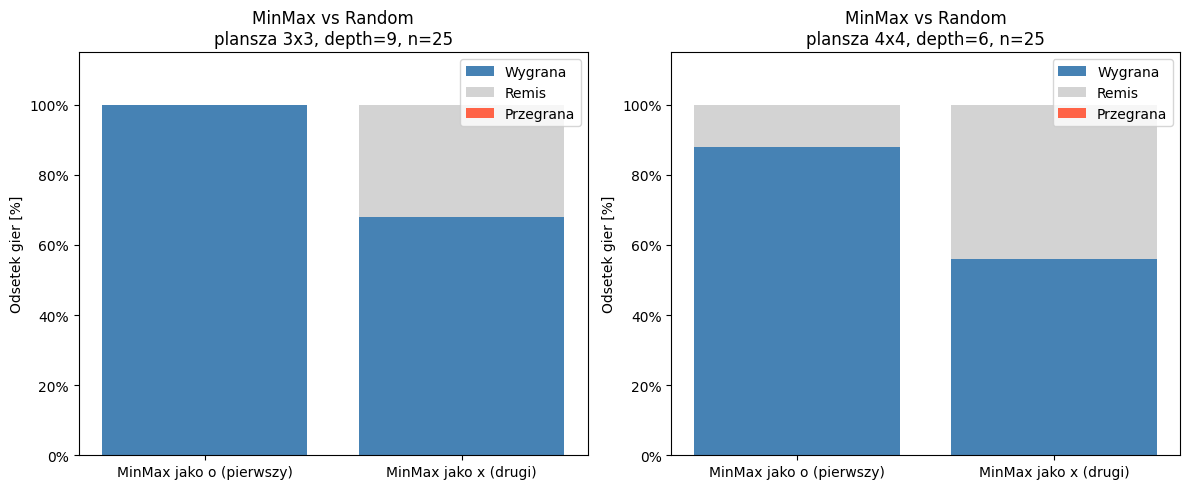

Saved: plots/exp1_minmax_vs_random.png


In [6]:
# Author: Wiktor Sosnowski
# Plot: stacked bar — win/draw/loss % per configuration

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, bsize in zip(axes, [3, 4]):
    sub = summary_mvr[summary_mvr['board_size'] == bsize].copy()
    labels = ['MinMax jako o (pierwszy)', 'MinMax jako x (drugi)']
    wins   = sub['win_%'].values
    draws  = sub['draw_%'].values
    losses = sub['loss_%'].values
    x = np.arange(len(labels))

    ax.bar(x, wins,   label='Wygrana',    color='steelblue')
    ax.bar(x, draws,  bottom=wins,        label='Remis',     color='lightgray')
    ax.bar(x, losses, bottom=wins+draws,  label='Przegrana', color='tomato')

    depth = int(sub['depth_limit'].values[0])
    ax.set_title(
        f'MinMax vs Random\nplansza {bsize}x{bsize}, depth={depth}, n=25'
    )
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylabel('Odsetek gier [%]')
    ax.set_ylim(0, 115)
    ax.legend(loc='upper right')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter())

plt.tight_layout()
plt.savefig('plots/exp1_minmax_vs_random.png', dpi=150)
plt.show()
print('Saved: plots/exp1_minmax_vs_random.png')

In [7]:
# Author: Wiktor Sosnowski
df_mvr_all.to_csv('results/exp1_minmax_vs_random_raw.csv', index=False)
summary_mvr.to_csv('results/exp1_minmax_vs_random_summary.csv', index=False)
print('Saved Experiment 1 results.')

Saved Experiment 1 results.


---
## Experiment 2 — MinMax vs MinMax: varying depth

Obaj gracze używają MinMax z alfa-beta. Testujemy wszystkie kombinacje par głębokości.  
Gry są w pełni deterministyczne — jedno uruchomienie na konfigurację.

Badane głębokości:
- Plansza 3x3: {1, 2, 3, 4, 9}
- Plansza 4x4: {1, 2, 3, 4, 6}

Dla każdej pary (depth_A, depth_B): MinMax(A) gra jako 'o', MinMax(B) gra jako 'x'.

In [8]:
# Author: Wiktor Sosnowski

DEPTHS_3x3 = [1, 2, 3, 4, 9]
DEPTHS_4x4 = [1, 2, 3, 4, 6]


def run_minmax_vs_minmax(board_size: int, depths: list) -> pd.DataFrame:
    """Run MinMax(d_a) as 'o' vs MinMax(d_b) as 'x' for every ordered pair."""
    records = []
    for d_a, d_b in itertools.product(depths, repeat=2):
        res = run_game(
            board_size,
            MinMaxPlayer('o', d_a),
            MinMaxPlayer('x', d_b)
        )
        winner = res['winner']
        outcome = 'o_wins' if winner == 'o' else ('x_wins' if winner == 'x' else 'draw')
        records.append({
            'board_size': board_size,
            'depth_o': d_a,
            'depth_x': d_b,
            'outcome': outcome,
            'turns': res['turns'],
            'time_o_ms': round(res['time_ms']['o'], 2),
            'time_x_ms': round(res['time_ms']['x'], 2),
        })
    return pd.DataFrame(records)


print('Running Experiment 2 — MinMax vs MinMax (3x3)...')
df_mvm_3 = run_minmax_vs_minmax(board_size=3, depths=DEPTHS_3x3)
print('Running Experiment 2 — MinMax vs MinMax (4x4)...')
df_mvm_4 = run_minmax_vs_minmax(board_size=4, depths=DEPTHS_4x4)

df_mvm_all = pd.concat([df_mvm_3, df_mvm_4], ignore_index=True)
print('Done.')

Running Experiment 2 — MinMax vs MinMax (3x3)...
Running Experiment 2 — MinMax vs MinMax (4x4)...
Done.


In [9]:
# Author: Wiktor Sosnowski
# Pivot result matrix: rows = depth_o, columns = depth_x

def result_matrix(df: pd.DataFrame, depths: list) -> pd.DataFrame:
    pivot = df.pivot(index='depth_o', columns='depth_x', values='outcome')
    return pivot.reindex(index=depths, columns=depths)


mat_3 = result_matrix(df_mvm_3, DEPTHS_3x3)
mat_4 = result_matrix(df_mvm_4, DEPTHS_4x4)

print('\n--- 3x3 outcome matrix (wiersze=depth_o, kolumny=depth_x) ---')
print(mat_3.to_string())
print('\n--- 4x4 outcome matrix (wiersze=depth_o, kolumny=depth_x) ---')
print(mat_4.to_string())


--- 3x3 outcome matrix (wiersze=depth_o, kolumny=depth_x) ---
depth_x       1     2     3       4     9
depth_o                                  
1        o_wins  draw  draw    draw  draw
2        o_wins  draw  draw    draw  draw
3        o_wins  draw  draw    draw  draw
4        o_wins  draw  draw    draw  draw
9          draw  draw  draw  o_wins  draw

--- 4x4 outcome matrix (wiersze=depth_o, kolumny=depth_x) ---
depth_x     1     2     3     4     6
depth_o                              
1        draw  draw  draw  draw  draw
2        draw  draw  draw  draw  draw
3        draw  draw  draw  draw  draw
4        draw  draw  draw  draw  draw
6        draw  draw  draw  draw  draw


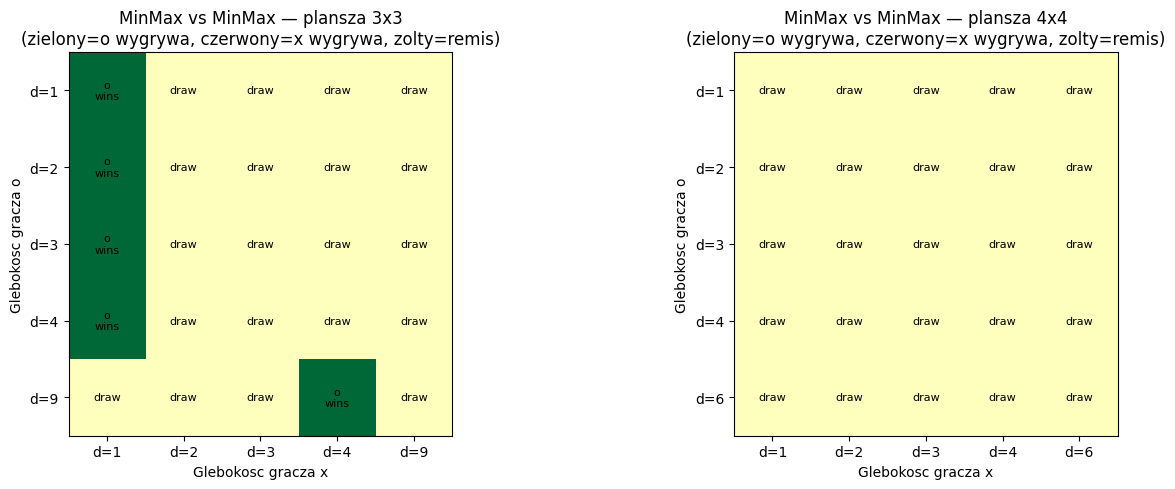

Saved: plots/exp2_minmax_vs_minmax_heatmap.png


In [10]:
# Author: Wiktor Sosnowski
# Heatmap of outcomes

OUTCOME_VAL = {'o_wins': 1, 'draw': 0, 'x_wins': -1}


def plot_result_heatmap(df, depths, board_size, ax):
    mat = result_matrix(df, depths)
    num_mat = mat.map(lambda v: OUTCOME_VAL.get(v, 0))

    ax.imshow(num_mat.values.astype(float), cmap='RdYlGn', vmin=-1, vmax=1)
    ax.set_xticks(range(len(depths)))
    ax.set_yticks(range(len(depths)))
    ax.set_xticklabels([f'd={d}' for d in depths])
    ax.set_yticklabels([f'd={d}' for d in depths])
    ax.set_xlabel('Glebokosc gracza x')
    ax.set_ylabel('Glebokosc gracza o')
    ax.set_title(
        f'MinMax vs MinMax — plansza {board_size}x{board_size}\n'
        '(zielony=o wygrywa, czerwony=x wygrywa, zolty=remis)'
    )
    for i, d_o in enumerate(depths):
        for j, d_x in enumerate(depths):
            val = mat.loc[d_o, d_x]
            ax.text(j, i, str(val).replace('_', '\n'),
                    ha='center', va='center', fontsize=8)


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_result_heatmap(df_mvm_3, DEPTHS_3x3, 3, axes[0])
plot_result_heatmap(df_mvm_4, DEPTHS_4x4, 4, axes[1])
plt.tight_layout()
plt.savefig('plots/exp2_minmax_vs_minmax_heatmap.png', dpi=150)
plt.show()
print('Saved: plots/exp2_minmax_vs_minmax_heatmap.png')

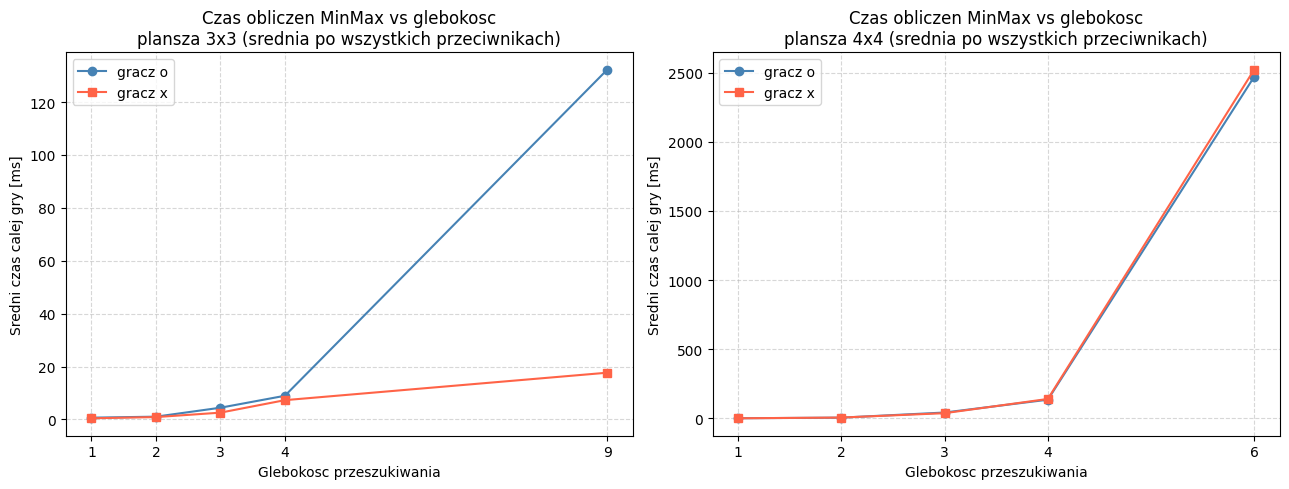

Saved: plots/exp2_time_vs_depth.png


In [11]:
# Author: Wiktor Sosnowski
# Plot: computation time vs depth

def plot_time_vs_depth(df, depths, board_size, ax):
    time_o = df.groupby('depth_o')['time_o_ms'].mean().reindex(depths)
    time_x = df.groupby('depth_x')['time_x_ms'].mean().reindex(depths)
    ax.plot(depths, time_o.values, marker='o', label='gracz o', color='steelblue')
    ax.plot(depths, time_x.values, marker='s', label='gracz x', color='tomato')
    ax.set_title(
        f'Czas obliczen MinMax vs glebokosc\n'
        f'plansza {board_size}x{board_size} (srednia po wszystkich przeciwnikach)'
    )
    ax.set_xlabel('Glebokosc przeszukiwania')
    ax.set_ylabel('Sredni czas calej gry [ms]')
    ax.legend()
    ax.set_xticks(depths)
    ax.grid(True, linestyle='--', alpha=0.5)


fig, axes = plt.subplots(1, 2, figsize=(13, 5))
plot_time_vs_depth(df_mvm_3, DEPTHS_3x3, 3, axes[0])
plot_time_vs_depth(df_mvm_4, DEPTHS_4x4, 4, axes[1])
plt.tight_layout()
plt.savefig('plots/exp2_time_vs_depth.png', dpi=150)
plt.show()
print('Saved: plots/exp2_time_vs_depth.png')

In [12]:
# Author: Wiktor Sosnowski
# Save Experiment 2 results

df_mvm_all.to_csv('results/exp2_minmax_vs_minmax_raw.csv', index=False)
mat_3.to_csv('results/exp2_outcome_matrix_3x3.csv')
mat_4.to_csv('results/exp2_outcome_matrix_4x4.csv')

time_3 = df_mvm_3.groupby('depth_o')[['time_o_ms']].mean().round(2)
time_4 = df_mvm_4.groupby('depth_o')[['time_o_ms']].mean().round(2)
time_3.to_csv('results/exp2_time_summary_3x3.csv')
time_4.to_csv('results/exp2_time_summary_4x4.csv')

print('Saved all Experiment 2 results.')
print('\nTime summary 3x3:')
print(time_3.to_string())
print('\nTime summary 4x4:')
print(time_4.to_string())

Saved all Experiment 2 results.

Time summary 3x3:
         time_o_ms
depth_o           
1             0.68
2             1.06
3             4.44
4             8.96
9           132.27

Time summary 4x4:
         time_o_ms
depth_o           
1             1.57
2             6.12
3            43.12
4           135.79
6          2469.85
